<a href="https://colab.research.google.com/github/Sridatta-Bharadwaj/minor-intro-to-ML/blob/main/decision_tree_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
import seaborn as sn

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("akshaydattatraykhare/diabetes-dataset")

print("Path to dataset files:", path)

100%|██████████| 8.91k/8.91k [00:00<00:00, 4.02MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/akshaydattatraykhare/diabetes-dataset/versions/1


In [13]:
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']

data = pd.read_csv(f"{path}/diabetes.csv", skiprows = 1, header=None, names=col_names)

In [14]:
print(data.shape)

data.head()

(768, 9)


,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [15]:
data.isnull().sum()

,0
pregnant,0
glucose,0
bp,0
skin,0
insulin,0
bmi,0
pedigree,0
age,0
label,0


In [16]:
feature_cols =['pregnant', 'insulin', 'bmi', 'age', 'glucose', 'bp', 'pedigree']

x = data[feature_cols]
y = data.label

In [8]:
x

,pregnant,insulin,bmi,age,glucose,bp,pedigree
0,Pregnancies,Insulin,BMI,Age,Glucose,BloodPressure,DiabetesPedigreeFunction
1,6,0,33.6,50,148,72,0.627
2,1,0,26.6,31,85,66,0.351
3,8,0,23.3,32,183,64,0.672
4,1,94,28.1,21,89,66,0.167
...,...,...,...,...,...,...,...
764,10,180,32.9,63,101,76,0.171
765,2,0,36.8,27,122,70,0.34
766,5,112,26.2,30,121,72,0.245
767,1,0,30.1,47,126,60,0.349


In [17]:
y

,label
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 5)

In [19]:
display(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(614, 7)

(614,)

(154, 7)

(154,)

In [20]:
model = DecisionTreeClassifier(criterion = 'entropy', random_state = 5)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print('y_pred: ', y_pred)
print('y_test: ', y_test)

y_pred:  [1 0 0 1 0 0 1 1 1 1 0 0 0 0 0 0 0 1 1 0 0 1 0 1 0 0 0 1 0 0 0 1 0 0 1 0 1
 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 1 1 1 1 0 1
 1 1 0 1 1 0 1 1 1 1 0 0 0 0 0 1 0 0 0 1 0 1 1 1 0 0 0 0 1 1 0 1 0 0 1 0 0
 0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 1 0 1 0 0 0 1
 0 0 1 1 0 1]
y_test:  567    0
123    0
615    0
492    0
288    0
      ..
432    0
480    1
7      0
564    0
40     0
Name: label, Length: 154, dtype: int64


In [23]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)
print('confusion matrix: ', conf_mat)

Accuracy_score = metrics.accuracy_score(y_test, y_pred)
print('Accuracy score: ', Accuracy_score)
print('Accuracy in percentage: ', int(Accuracy_score * 100), '%')

confusion matrix:  [[77 23]
 [19 35]]
Accuracy score:  0.7272727272727273
Accuracy in percentage:  72 %


<Axes: xlabel='predicted', ylabel='Actual'>

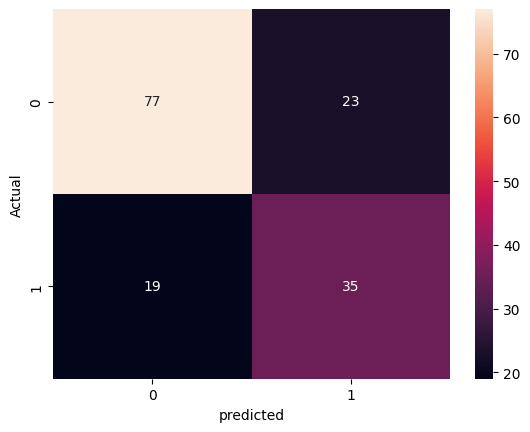

In [25]:
conf_mat = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['predicted'])

sn.heatmap(conf_mat, annot = True)